In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()


df = pd.read_csv("Customer-Churn.csv")

Saving Customer-Churn.csv to Customer-Churn.csv


In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['TotalCharges'].head(10)


,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


In [ ]:
df['TotalCharges'].dtype

dtype('O')

In [ ]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
# Step 1: clean spaces
df['TotalCharges'] = df['TotalCharges'].astype(str).str.strip()

In [ ]:
# Step 2: convert to number (IMPORTANT)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
# Step 3: handle missing
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [ ]:
df['CLV'] = df['MonthlyCharges'] * df['tenure']

In [ ]:
bins = [0,12,24,48,72]

In [ ]:
labels = [
'New',
'1-2 Years',
'2-4 Years',
'4+ Years'
]

In [ ]:
df['TenureGroup'] = pd.cut(
df['tenure'],
bins=bins,
labels=labels
)

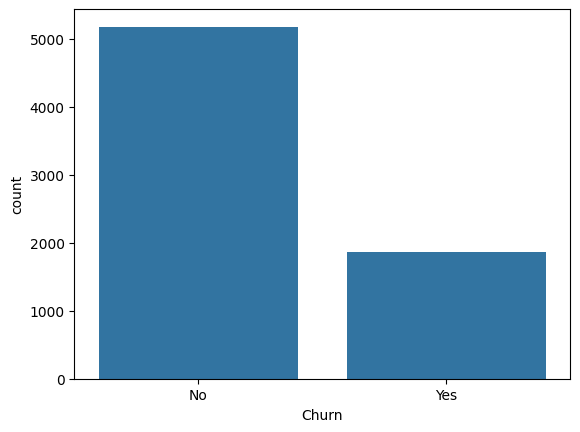

In [ ]:
sns.countplot(
x='Churn',
data=df
)
plt.show()

In [ ]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [ ]:
pd.crosstab(
df['Contract'],
df['Churn']
)

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


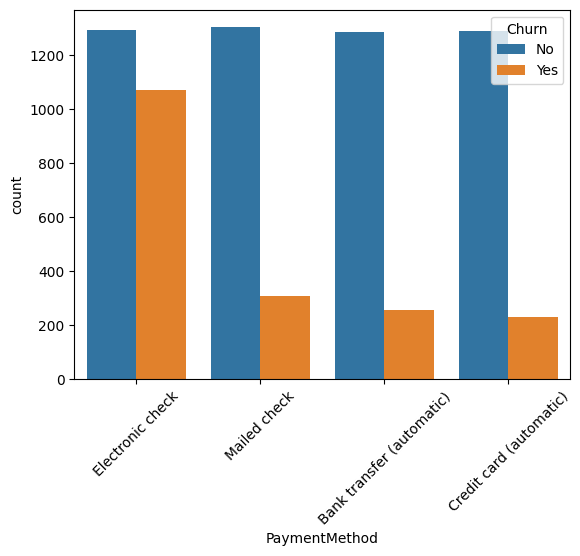

In [ ]:
sns.countplot(
x='PaymentMethod',
hue='Churn',
data=df
)

plt.xticks(rotation=45)
plt.show()

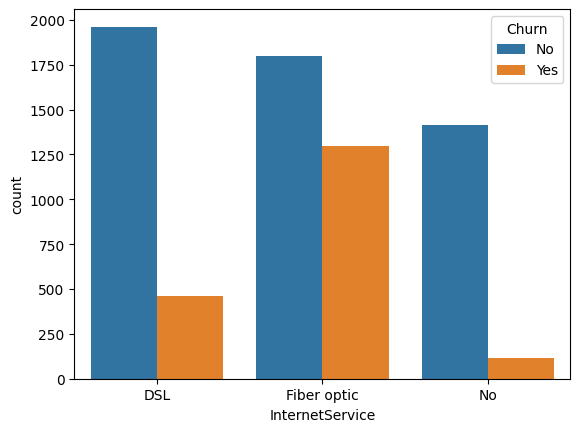

In [ ]:
sns.countplot(
x='InternetService',
hue='Churn',
data=df
)

plt.show()

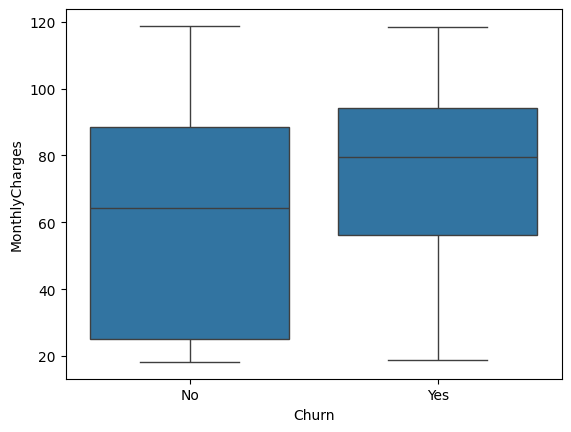

In [ ]:
sns.boxplot(
x='Churn',
y='MonthlyCharges',
data=df
)

plt.show()

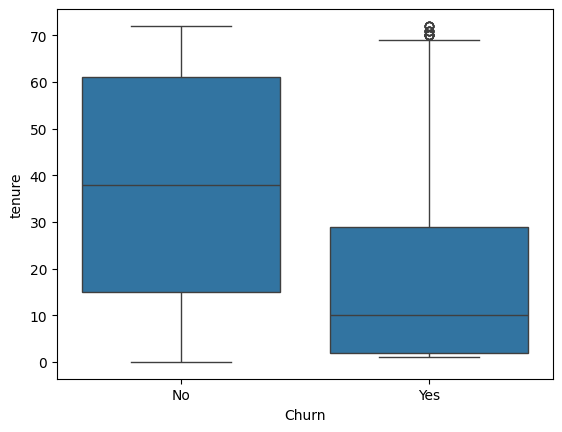

In [ ]:
sns.boxplot(
x='Churn',
y='tenure',
data=df
)

plt.show()

In [ ]:
corr = df.corr(numeric_only=True)

corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,CLV
SeniorCitizen,1.000000,0.016567,0.220173,0.102652,0.103261
tenure,0.016567,1.000000,0.247900,0.825464,0.826568
MonthlyCharges,0.220173,0.247900,1.000000,0.650864,0.651566
TotalCharges,0.102652,0.825464,0.650864,1.000000,0.999263
CLV,0.103261,0.826568,0.651566,0.999263,1.000000


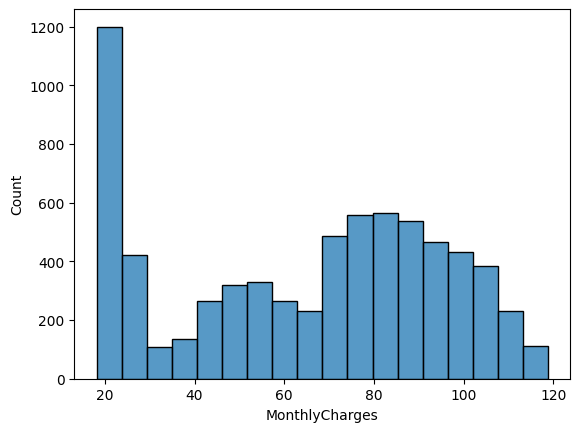

In [ ]:
sns.histplot(
df['MonthlyCharges']
)

plt.show()

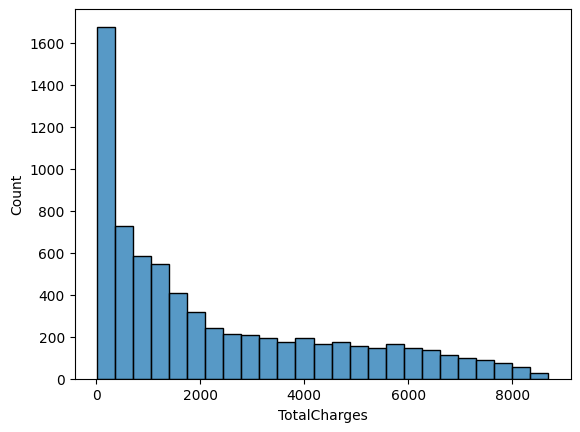

In [ ]:
sns.histplot(
df['TotalCharges']
)

plt.show()

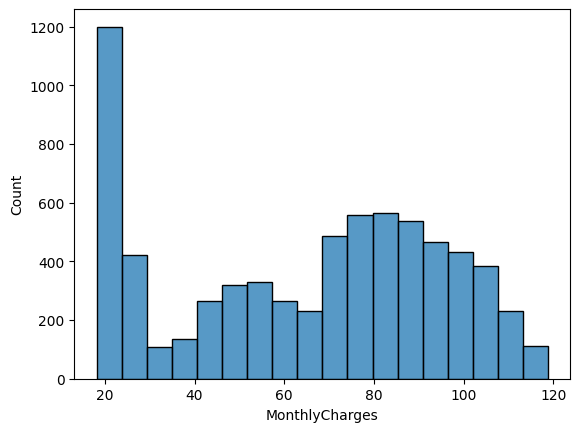

In [ ]:
sns.histplot(
df['MonthlyCharges']
)

plt.show()

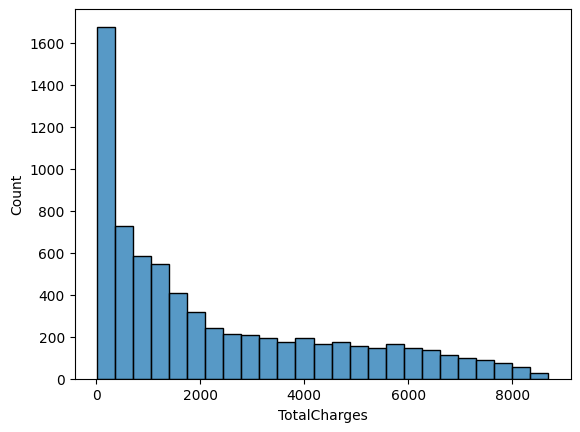

In [ ]:
sns.histplot(
df['TotalCharges']
)

plt.show()

In [ ]:
pd.crosstab(
df['SeniorCitizen'],
df['Churn']
)

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


In [ ]:
pd.crosstab(
df['Partner'],
df['Churn']
)

Churn,No,Yes
Partner,,
No,2441,1200
Yes,2733,669


In [ ]:
pd.crosstab(
df['Dependents'],
df['Churn']
)

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1784,326


In [ ]:
pd.crosstab(
df['TechSupport'],
df['Churn']
)

Churn,No,Yes
TechSupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


In [ ]:
pd.crosstab(
df['OnlineSecurity'],
df['Churn']
)

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


In [ ]:
total_customers = df.shape[0]

print("Total Customers :", total_customers)

Total Customers : 7043


In [ ]:
churn_rate = (
    (df['Churn'] == 'Yes').mean()
) * 100

print("Churn Rate :", round(churn_rate,2),"%")

Churn Rate : 26.54 %


In [ ]:
(df['Churn']=='Yes')

,Churn
0,False
1,False
2,True
3,False
4,True
...,...
7038,False
7039,False
7040,False
7041,True


In [ ]:
avg_revenue = df['MonthlyCharges'].mean()

print("Average Monthly Revenue :", round(avg_revenue,2))

Average Monthly Revenue : 64.76


In [ ]:
avg_tenure = df['tenure'].mean()

print("Average Tenure :", round(avg_tenure,2))

Average Tenure : 32.37


In [ ]:
lost = df[df['Churn']=='Yes']

revenue_lost = lost['MonthlyCharges'].sum()

print("Revenue Lost :", round(revenue_lost,2))

Revenue Lost : 139130.85


In [ ]:
df['Segment'] = 'Normal'

In [ ]:
df.loc[
    df['CLV'] > 3000,
    'Segment'
] = 'High Value'

In [ ]:
df.loc[
    df['Churn'] == 'Yes',
    'Segment'
] = 'Churned'

In [ ]:
df['Segment'].value_counts()

,count
Segment,
Normal,3317
Churned,1869
High Value,1857


In [ ]:
segment_summary = df.groupby(
    'Segment'
)['MonthlyCharges'].mean()

segment_summary

,MonthlyCharges
Segment,
Churned,74.441332
High Value,89.188988
Normal,45.632137


In [ ]:
df['Recency'] = df['tenure']

In [ ]:
service_cols = [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

In [ ]:
df['Frequency'] = (
    df[service_cols]
    .replace({
        'Yes':1,
        'No':0,
        'No internet service':0,
        'No phone service':0
    })
    .sum(axis=1)
)

/tmp/ipykernel_743/3032620654.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


In [ ]:
for col in service_cols:
    print(col)
    print(df[col].unique())
    print("----------------")

PhoneService
['No' 'Yes']
----------------
OnlineSecurity
['No' 'Yes' 'No internet service']
----------------
OnlineBackup
['Yes' 'No' 'No internet service']
----------------
DeviceProtection
['No' 'Yes' 'No internet service']
----------------
TechSupport
['No' 'Yes' 'No internet service']
----------------
StreamingTV
['No' 'Yes' 'No internet service']
----------------
StreamingMovies
['No' 'Yes' 'No internet service']
----------------


In [ ]:
df['Frequency'].head()

,Frequency
0,1
1,3
2,3
3,3
4,1


In [ ]:
df['Monetary'] = df['MonthlyCharges']

In [ ]:
df['R_Score'] = pd.qcut(
    df['Recency'],
    4,
    labels=[1,2,3,4]
)

In [ ]:
df['F_Score'] = pd.qcut(
    df['Frequency'],
    4,
    labels=[1,2,3,4],
    duplicates='drop'
)

In [ ]:
df['M_Score'] = pd.qcut(
    df['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [ ]:
df['RFM_Score'] = (
    df['R_Score'].astype(int)
    +
    df['F_Score'].astype(int)
    +
    df['M_Score'].astype(int)
)

In [ ]:
df['RFM_Segment'] = 'Lost'

df.loc[
    df['RFM_Score'] >= 10,
    'RFM_Segment'
] = 'Champions'

df.loc[
    (df['RFM_Score'] >= 7) &
    (df['RFM_Score'] < 10),
    'RFM_Segment'
] = 'Loyal'

df.loc[
    (df['RFM_Score'] >= 4) &
    (df['RFM_Score'] < 7),
    'RFM_Segment'
] = 'At Risk'

In [ ]:
df['RFM_Segment'].value_counts()

,count
RFM_Segment,
At Risk,2761
Loyal,1923
Champions,1822
Lost,537


In [ ]:
df.to_csv("customer_churn_cleaned.csv", index=False)

from google.colab import files
files.download("customer_churn_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>